[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NicoRota-0/DIGA_RNA/blob/main/dataset.ipynb)

# Dataset di interazioni snoRNA-lncRNA
Questo notebook serve per analizzare un dataset che contiene coppie di RNA non codificanti (snoRNA-lncRNA) che interagiscono tra loro.

In particolare:
lavoriamo con interazioni validate sperimentalmente (esempi “positivi”)
useremo questi dati più avanti per addestrare e testare un modello di machine learning

In [8]:
# In questo notebook ci servirà:
# 1. Una lista di coppie di esempi positivi
#    (interazioni ncRNA–ncRNA validate sperimentalmente)

# scarichiamo il repository con i dati da github su colab
!git clone https://github.com/NicoRota-0/DIGA_RNA

# Importiamo la libreria pandas
# pandas serve per lavorare con tabelle di dati (simili a Excel)
import pandas as pd

# Percorso del file CSV che contiene il dataset
df = pd.read_csv('DIGA_RNA/snorna_lncrna.csv')

# Mostriamo le prime 5 righe del dataset
df.head(5)

Cloning into 'DIGA_RNA'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 18 (delta 5), reused 8 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 9.46 MiB | 15.31 MiB/s, done.
Resolving deltas: 100% (5/5), done.


,RNA_sequence_x,RNA_sequence_y,Category_x,Category_y,Category_Couple
0,CGCAGCUUGUAGACAGCUUAGACGGGACAACGACCAGGGACAGCGA...,GCACUGUGCUAAAAUUGCAGGAACUAAGAUUCUAUCUUGGUUUUUG...,lncRNA,snoRNA,lncRNA - snoRNA
1,GGCCCCGCCCGCGCCGCCCCCGCGCGCUCGCGACCCCGGGAGGCCC...,GCAAAAACUGGAAAACAAGUGCAAGAACAAAUCCUCUUUUGCAACC...,lncRNA,snoRNA,lncRNA - snoRNA
2,GGUCUCUUUGUGCACCCGCCCACACGGUUUGCCGUGUUUUCACCCU...,AGCCUCAUUGUACAUAAGAAUGGGCAUUGUUGGUCAUUGUCCAGAA...,lncRNA,snoRNA,lncRNA - snoRNA
3,GGUCUCUUUGUGCACCCGCCCACACGGUUUGCCGUGUUUUCACCCU...,AUGCAGGUACAGUUACAAUAAAACUGAAGUGUUCUAUUGUCGUUCC...,lncRNA,snoRNA,lncRNA - snoRNA
4,GGUCUCUUUGUGCACCCGCCCACACGGUUUGCCGUGUUUUCACCCU...,CUGCGAAUAUUCUCGCUGUUCUGAUUCUGUGAUAAUCAGGACAGGC...,lncRNA,snoRNA,lncRNA - snoRNA


### IL dataset è composto da tante righe, una riga corrisponde ad una interazione tra due RNA.

## Analizziamo le sequenze RNA presenti nel dataset.
Vogliamo rispondere a queste domande:
Quante sequenze RNA diverse ci sono nel dataset?
Le sequenze compaiono in coppie (x e y), ma alcune sequenze possono ripetersi.

Quanto sono lunghe le sequenze?
Calcoliamo la lunghezza di ogni sequenza, e visualizziamo la distribuzione con un istogramma.

In [13]:
# Controlliamo quante coppie di sequenze sono presenti nel dataset
print('Numero di coppie di sequenze: {}'.format(len(df)))

Numero di coppie di sequenze: 657


In [17]:
# Uniamo tutte le sequenze RNA delle due colonne (x e y)
# pd.concat serve a "mettere insieme" due colonne in una sola lista
all_sequences = pd.concat([df['RNA_sequence_x'], df['RNA_sequence_y']]).unique()

# Contiamo quante sequenze RNA diverse ci sono nel dataset
num_unique_sequences = len(all_sequences)
print(f"Numero di sequenze RNA uniche: {num_unique_sequences}")

# Calcoliamo la lunghezza (numero di nucleotidi) di ogni sequenza RNA
sequence_lengths = [len(seq) for seq in all_sequences]

# Importiamo matplotlib per creare grafici
import matplotlib.pyplot as plt

Numero di sequenze RNA uniche: 398


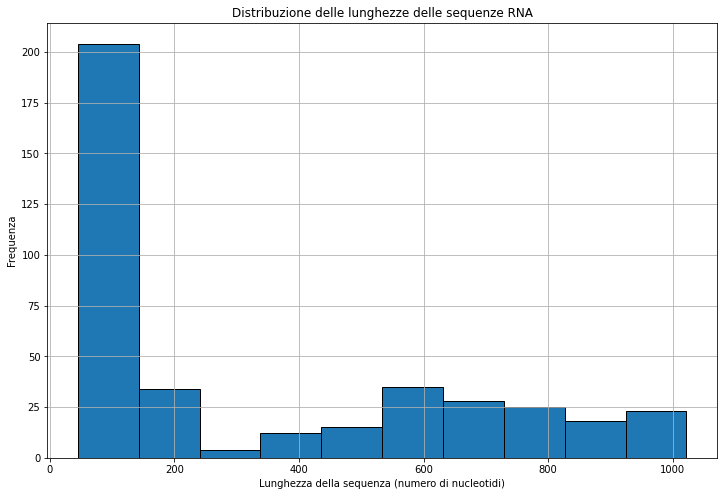

In [18]:
# Creiamo un istogramma della distribuzione delle lunghezze delle sequenze
plt.figure(figsize=(12, 8))
plt.hist(sequence_lengths, bins=10, edgecolor='black')
plt.title('Distribuzione delle lunghezze delle sequenze RNA')
plt.xlabel('Lunghezza della sequenza (numero di nucleotidi)')
plt.ylabel('Frequenza')
plt.grid(True)
plt.show()

### Esercizio nel codice

Cambia il numero di bins dell’istogramma (es. 3 o 100).

👉 Cosa cambia nella forma del grafico?

👉 Il dataset contiene più sequenze corte o lunghe?

In [20]:
# 👉 Qual è la sequenza più lunga? E la più corta?
print('Lunghezza massima: {}'.format(max(sequence_lengths)))
print('Lunghezza minima: {}'.format(min(sequence_lengths)))


Lunghezza massima: 1022
Lunghezza minima: 45


# Rappresentazione del dataset come grafo
In questa cella rappresentiamo il dataset come un grafo di interazioni.
L’idea è la seguente:
- ogni nodo rappresenta una sequenza RNA
- ogni arco (edge) rappresenta un’interazione tra due RNA


il grafo ci permette di visualizzare la struttura globale del dataset
Inoltre:
- coloriamo i nodi in base al tipo di RNA:
- lncRNA → giallo
- snoRNA → rosso

questo ci aiuta a capire se le interazioni sono:
- tra RNA dello stesso tipo
- oppure tra tipi diversi
Per costruire e visualizzare il grafo usiamo la libreria NetworkX.

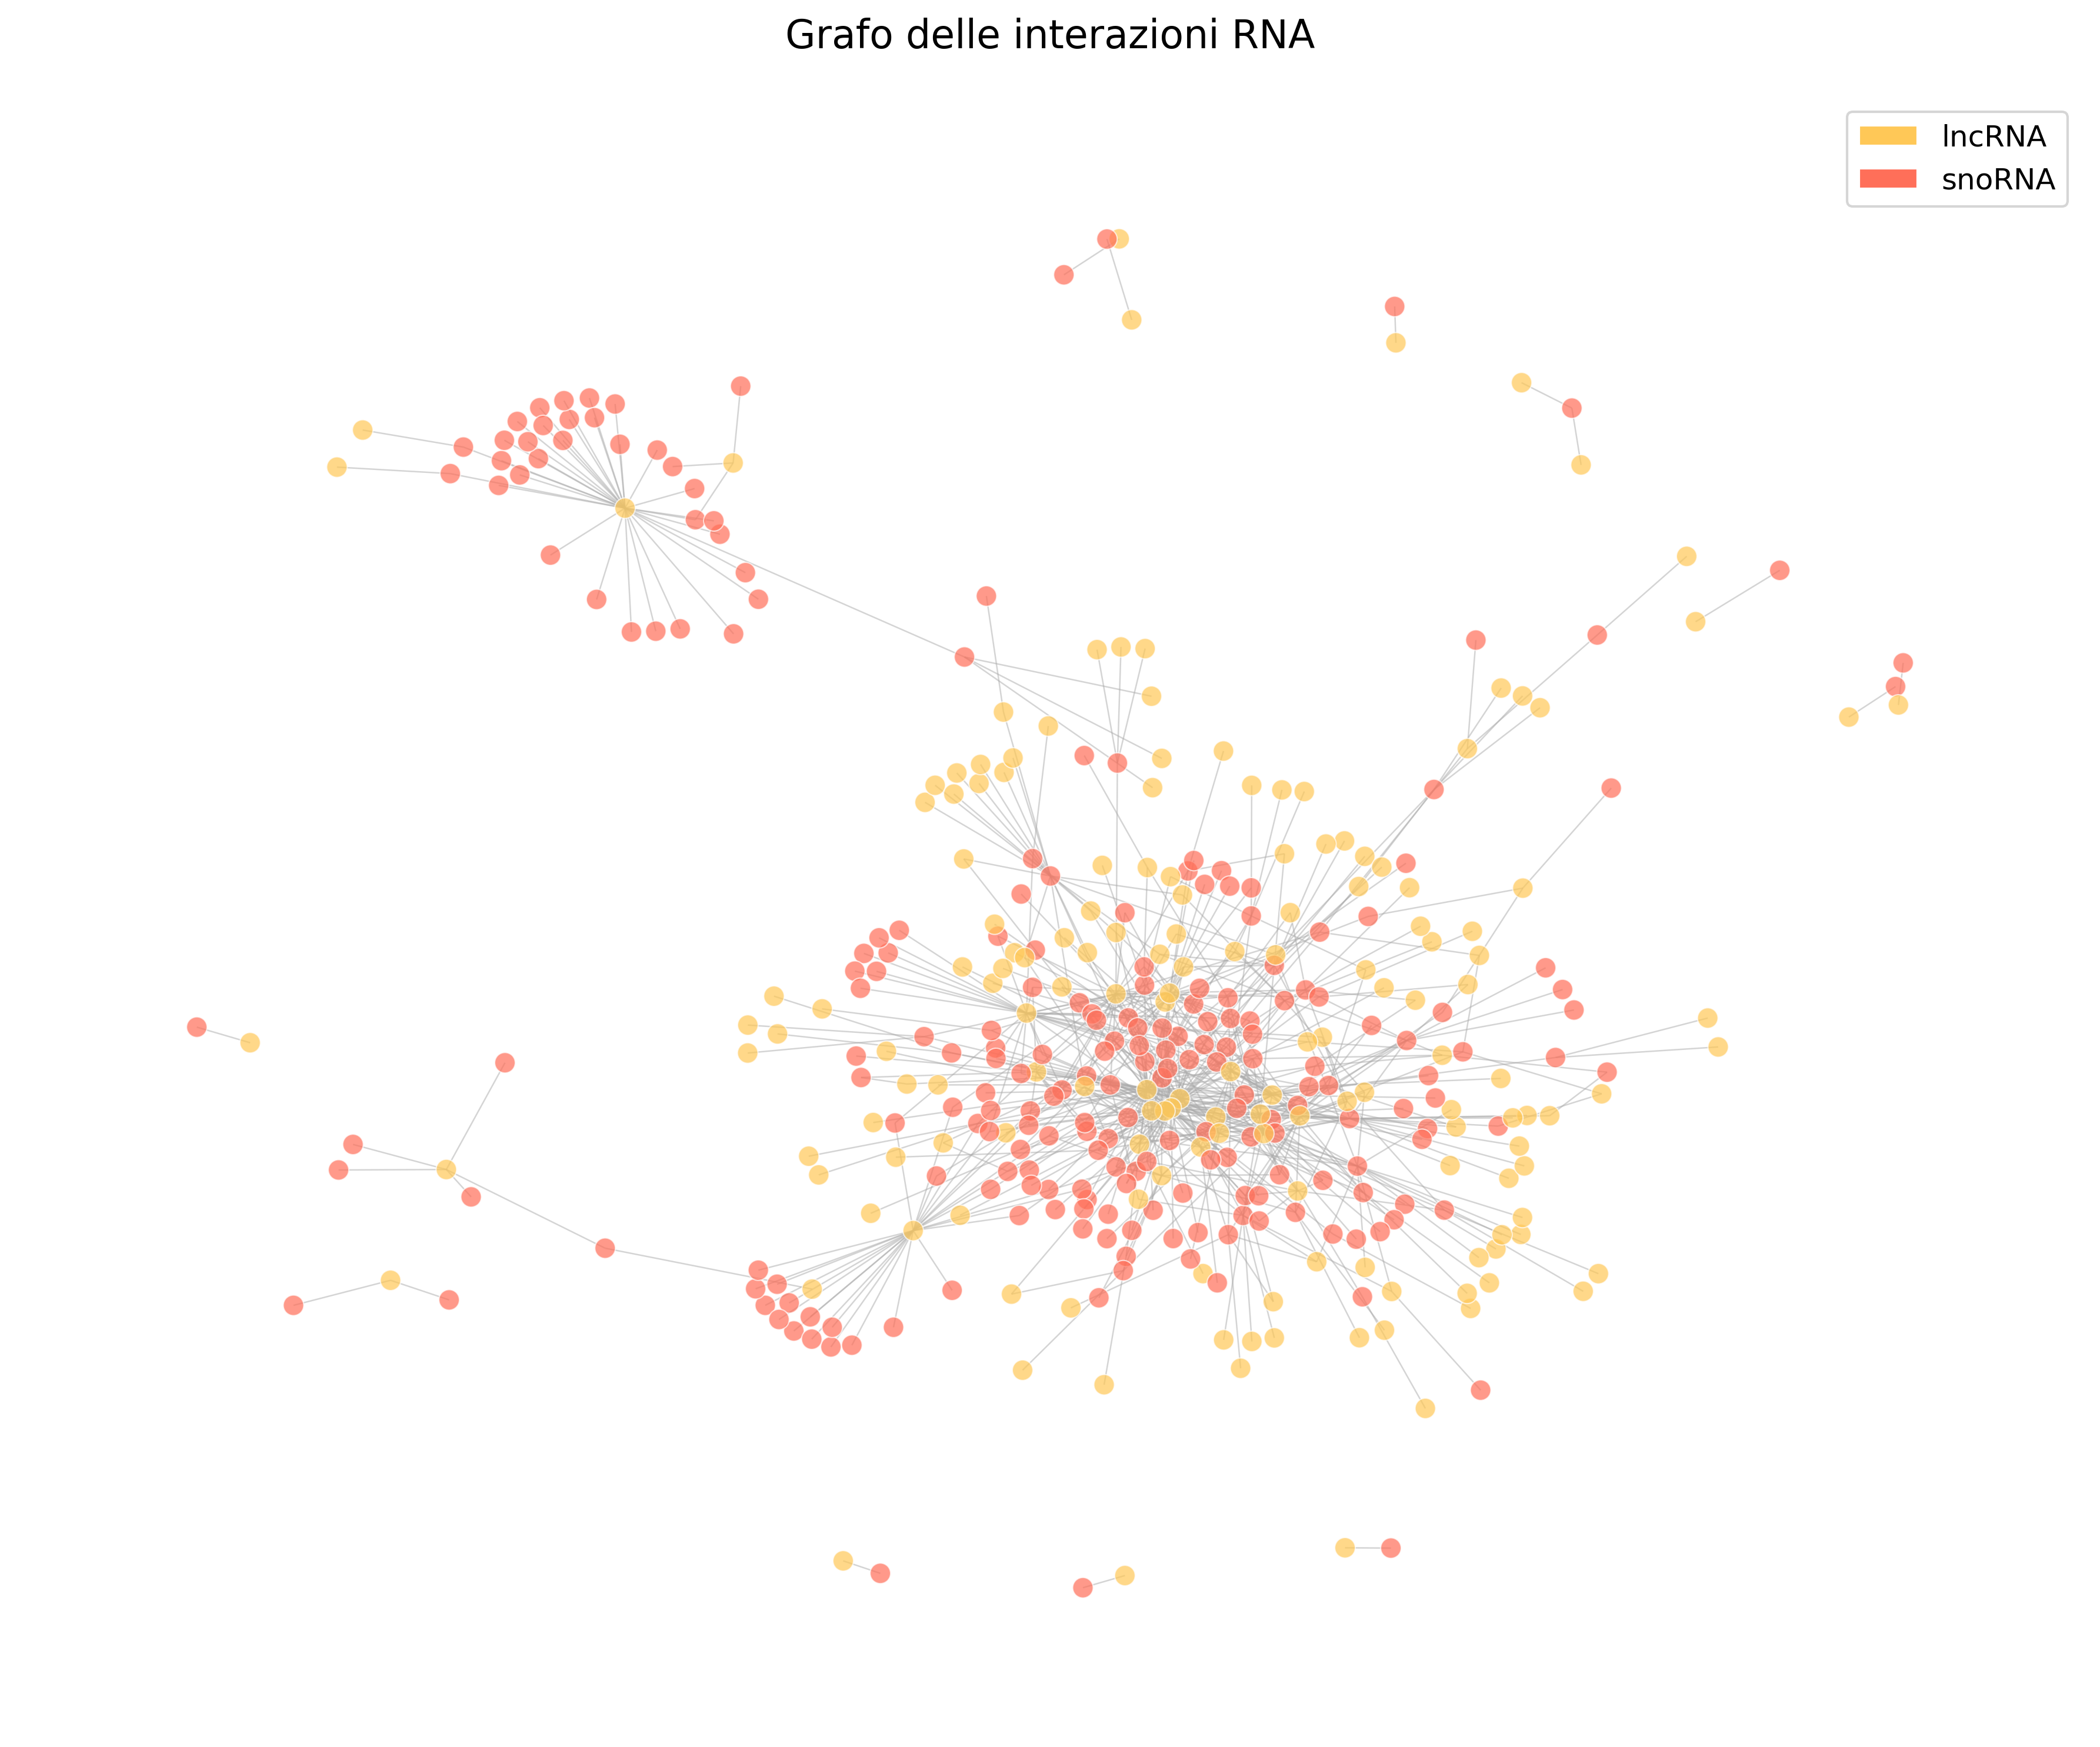

In [22]:
# definiamo la dimensione dei nodi per il grafo (X esercizio)
node_size = 70

# Importiamo la libreria networkx per lavorare con grafi
import networkx as nx

# Importiamo Patch per creare la legenda dei colori
from matplotlib.patches import Patch

# Costruiamo il grafo a partire dal dataframe filtrato
# Ogni riga del dataframe diventa un arco tra RNA_sequence_x e RNA_sequence_y
G = nx.from_pandas_edgelist(
    df,
    source="RNA_sequence_x",
    target="RNA_sequence_y"
)

# Creiamo una mappa che associa a ogni nodo un colore,
# in base alla categoria dell'RNA (lncRNA o snoRNA)
node_color_map = {}

for idx, row in df.iterrows():
    node_color_map[row['RNA_sequence_x']] = (
        '#ffc857' if row['Category_x'] == 'lncRNA' else '#ff6f59'
    )
    node_color_map[row['RNA_sequence_y']] = (
        '#ffc857' if row['Category_y'] == 'lncRNA' else '#ff6f59'
    )

# Creiamo la lista dei colori dei nodi nello stesso ordine di G.nodes()
node_colors = [node_color_map[node] for node in G.nodes()]

# Impostiamo la figura
plt.figure(figsize=(12, 10), dpi=300)

# Calcoliamo la posizione dei nodi usando un layout "a molle"
# I nodi collegati tendono a stare più vicini
pos = nx.spring_layout(G, k=0.4, iterations=200, seed=42)

# Disegniamo i nodi
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_size,
    node_color=node_colors,
    alpha=0.7,
    edgecolors="white",
    linewidths=0.5
)

# Disegniamo gli archi (interazioni)
nx.draw_networkx_edges(
    G,
    pos,
    width=0.6,
    alpha=0.5,
    edge_color="#aaaaaa"
)

# Creiamo la legenda per i colori dei nodi
legend_elements = [
    Patch(facecolor='#ffc857', edgecolor='white', label='lncRNA'),
    Patch(facecolor='#ff6f59', edgecolor='white', label='snoRNA')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

# Rimuoviamo gli assi e mostriamo il titolo
plt.axis("off")
plt.title("Grafo delle interazioni RNA", fontsize=16, pad=20)
plt.tight_layout()
plt.show()


## Esercizi sul Grafo

Esercizio 1

Cambia il valore di node_size (es. 30, 150).

👉 Come cambia la leggibilità del grafo?


# Suddivisione in training e test
In questo passo dividiamo il dataset in due parti:
- training set: dati usati per addestrare il modello classificatore
- test set: dati usati solo alla fine, per valutare le prestazioni


Questa divisione è fondamentale per:
- evitare che il modello “memorizzi” i dati su cui viene testato
- verificare se il modello generalizza su esempi mai visti prima


Useremo una funzione di scikit-learn, una libreria molto usata nel machine learning.
In questo caso:
- il 15% dei dati viene usato come test
- il resto viene usato per il training

In [ ]:
# Step 2: Suddivisione del dataset in training e test

# Importiamo la funzione per dividere i dati
from sklearn.model_selection import train_test_split

# Eseguiamo la divisione train / test
train_df, test_df = train_test_split(
    df,
    test_size=0.15     # Percentuale di dati usata per il test
)

# Controlliamo quante coppie ci sono nel training set
print("Numero di coppie nel training set:")
print(train_df.count())

# Controlliamo quante coppie ci sono nel test set
print("Numero di coppie nel test set:")
print(test_df.count())


Numero di coppie nel training set:
RNA_sequence_x     558
RNA_sequence_y     558
Category_x         558
Category_y         558
Category_Couple    558
dtype: int64
Numero di coppie nel test set:
RNA_sequence_x     99
RNA_sequence_y     99
Category_x         99
Category_y         99
Category_Couple    99
dtype: int64


# Estrazione delle rappresentazioni con RNA-FM e pooling
Il prossimo passo della pipeline, è rappresentazioni numeriche delle sequenze RNA usando un modello pre-addestrato come RNA-FM.

RNA-FM è un foundation model che:
- prende in input una sequenza RNA
- produce una rappresentazione vettoriale per ogni nucleotide
- cattura informazioni strutturali ed evolutive


Questo passaggio richiede hardware dedicato (GPU e molta memoria), quindi non lo eseguiremo in questo notebook.

## Cosa otteniamo dopo aver estratto le rappresentazioni di ogni RNA nel dataset?
Per ogni sequenza RNA otteniamo:
- un vettore numerico di dimensione fissa pronto per essere usato come input di un modello di machine learning

Nel nostro caso:
una coppia di RNA diventa una coppia di vettori che useremo per predire se interagiscono


# Positivi e negativi nel problema di predizione

Fino a ora abbiamo lavorato **solo con esempi positivi**, cioè:

* coppie di RNA (lncRNA–snoRNA)
* per cui l’interazione è stata osservata sperimentalmente

Per addestrare un modello di machine learning, però, servono anche **esempi negativi**:

* coppie di RNA che **non interagiscono**

---

### 🔹 Come definiamo i negativi in questo lavoro

In questo progetto:

* consideriamo **solo interazioni tra lncRNA e snoRNA**
* **escludiamo**:

  * lncRNA–lncRNA
  * snoRNA–snoRNA

👉 Un esempio negativo è quindi:

> una coppia *lncRNA–snoRNA* **che non compare** tra le interazioni positive

In termini di grafo:

* i **positivi** sono gli archi presenti
* i **negativi** sono tutti gli archi possibili *lncRNA–snoRNA* che **non esistono nel grafo**

* non usiamo *tutti* i negativi possibili, ma ne scegliamo 'a caso' solo una parte per avere la stessa quantità di negativi uguale ai positivi nel dataset.

---

## 📘 Lettura visiva del grafo delle interazioni dei negativi

Quando guardi il grafo delle interazioni:

* un arco grigio → **interazione positiva**
* due nodi di colore diverso **senza arco** → **possibile negativo**
* arco rosso → **interazione negativa**


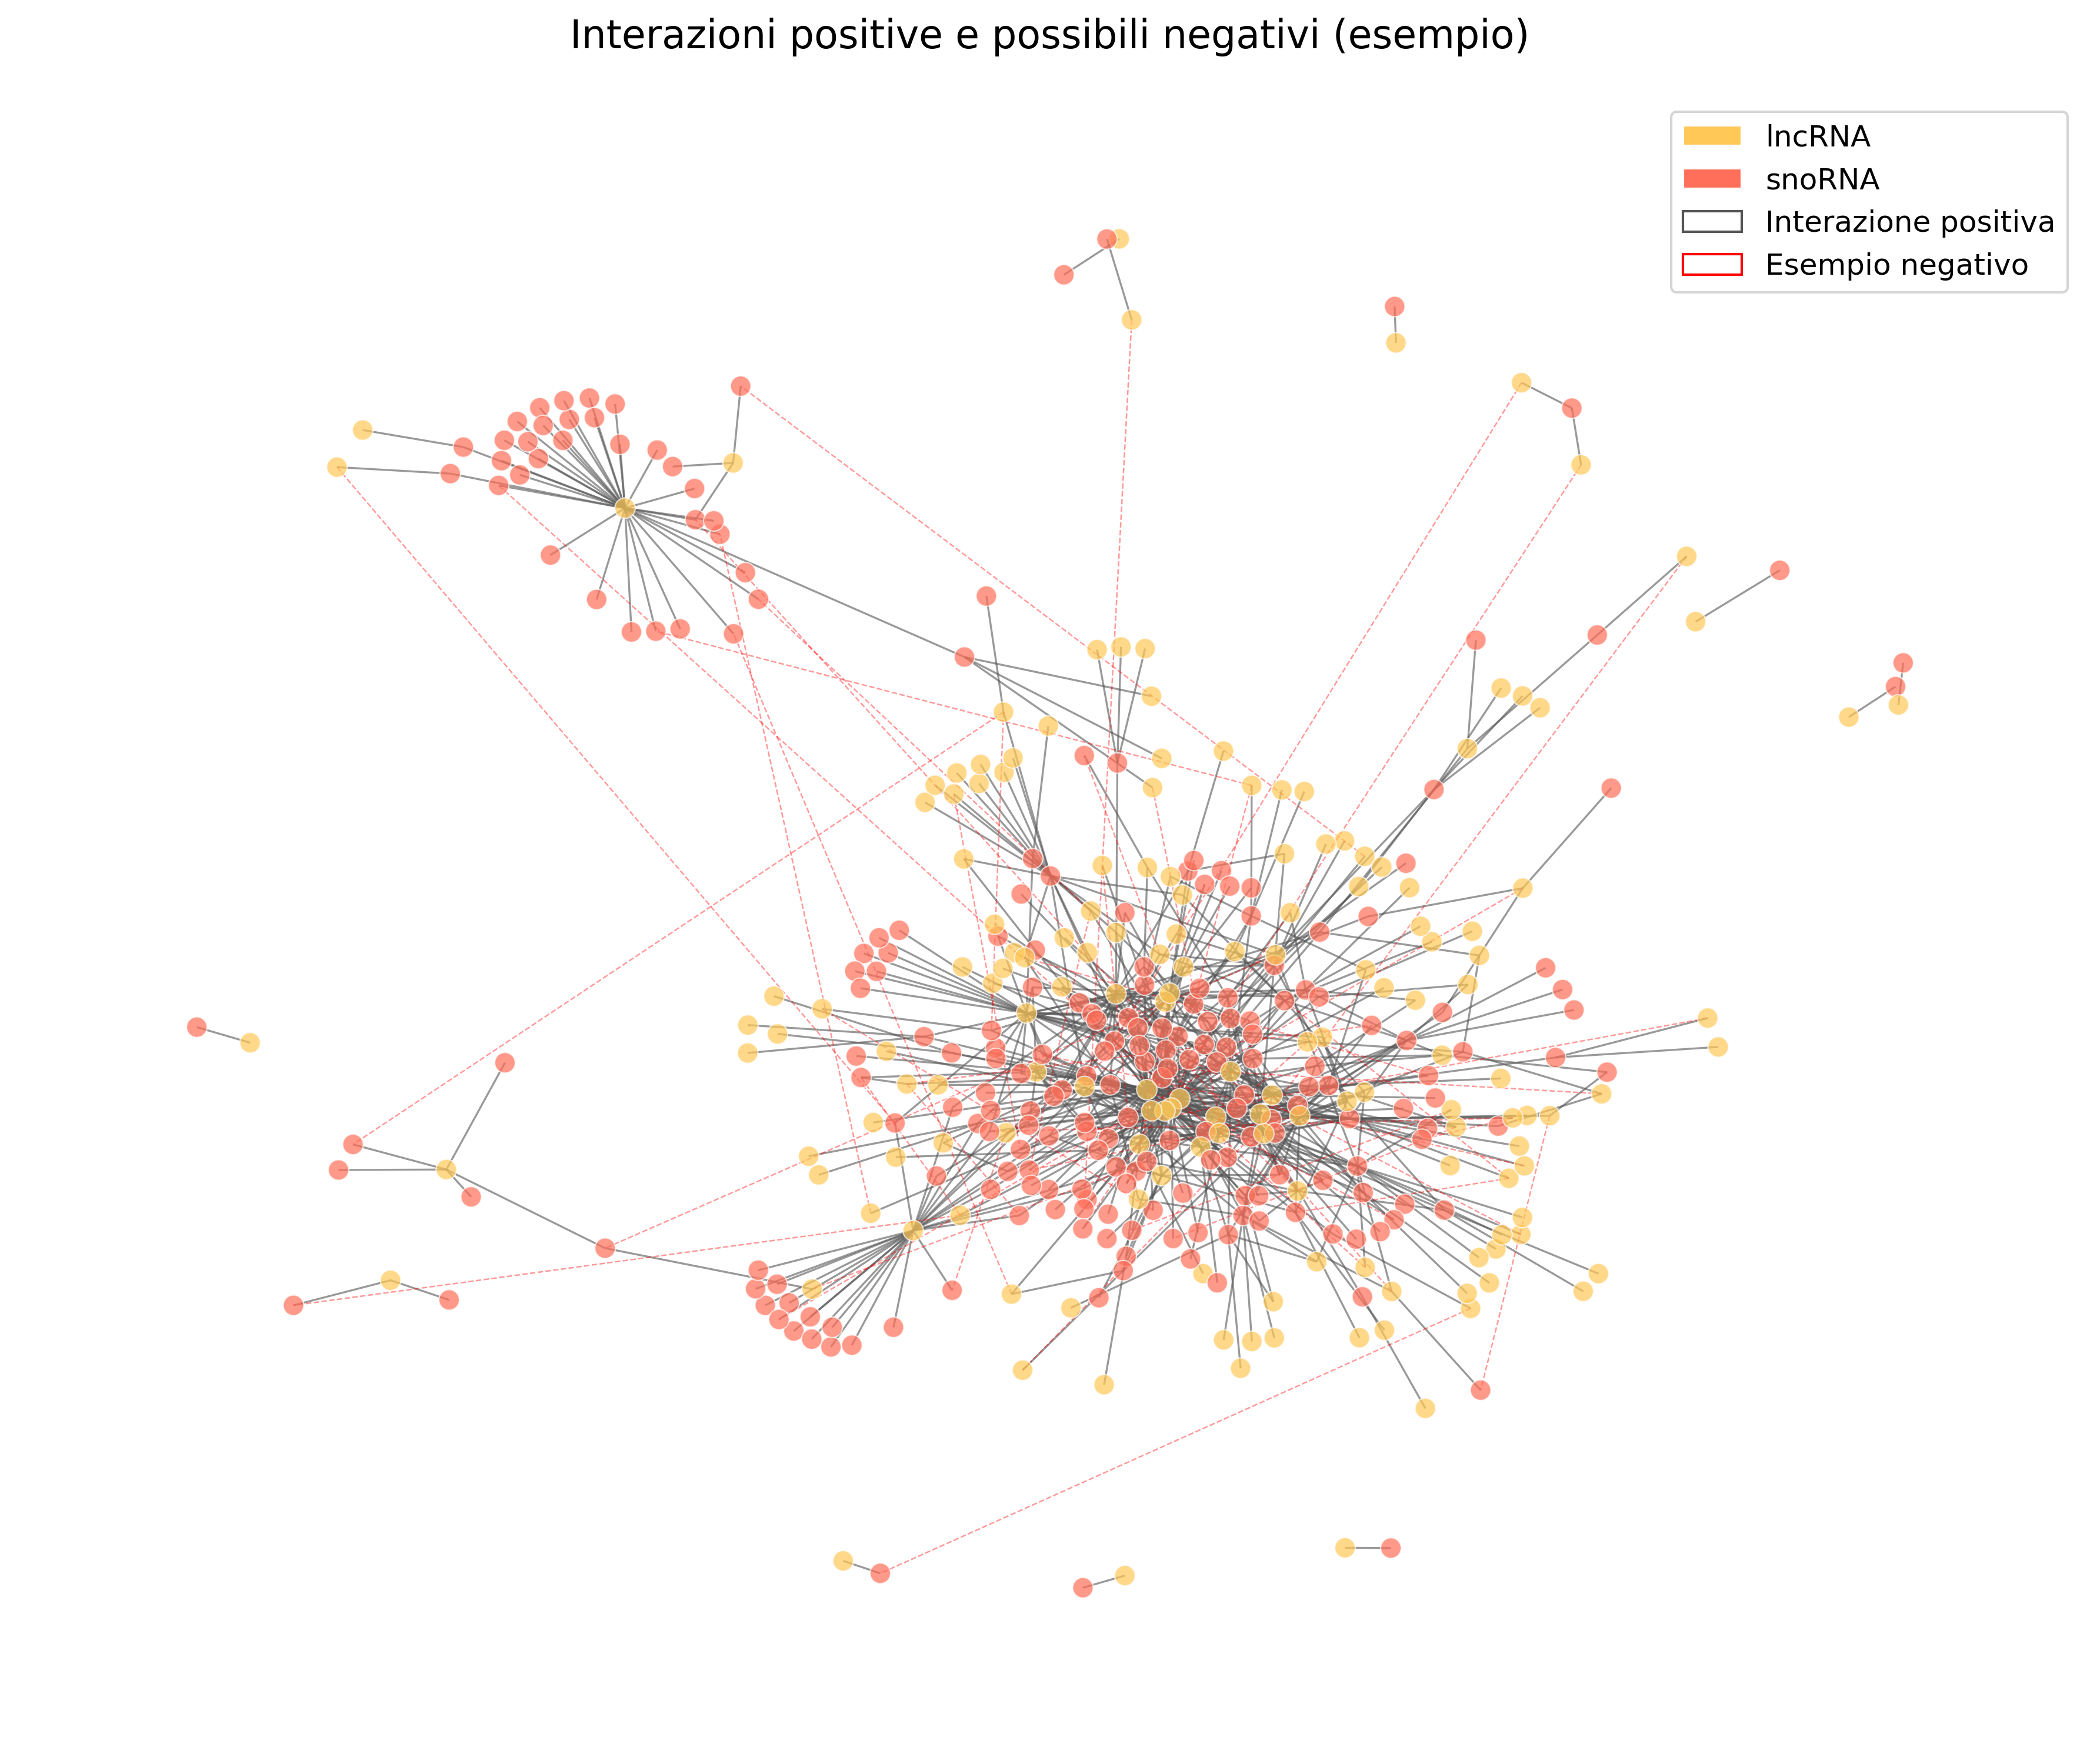

In [23]:
# Copiamo il grafo dei positivi che abbiamo creato prima
G_pos = G.copy()

# Costruiamo la lista di possibili negativi:
# coppie lncRNA–snoRNA che NON sono archi nel grafo
lnc_nodes = [
    node for node, color in node_color_map.items()
    if color == '#ffc857'
]
sno_nodes = [
    node for node, color in node_color_map.items()
    if color == '#ff6f59'
]

possible_negatives = [
    (l, s) for l in lnc_nodes for s in sno_nodes
    if not G_pos.has_edge(l, s)
]

# Campioniamo pochi negativi solo per visualizzazione
import random
random.seed(42)
sampled_negatives = random.sample(
    possible_negatives,
    k=min(50, len(possible_negatives))
)

# Disegniamo il grafo
plt.figure(figsize=(12, 10), dpi=300)

# Nodi
nx.draw_networkx_nodes(
    G_pos, pos,
    node_size=70,
    node_color=node_colors,
    alpha=0.7,
    edgecolors="white",
    linewidths=0.5
)

# Archi positivi (continui)
nx.draw_networkx_edges(
    G_pos, pos,
    width=0.8,
    alpha=0.6,
    edge_color="#555555"
)

# Archi negativi (tratteggiati)
nx.draw_networkx_edges(
    G_pos, pos,
    edgelist=sampled_negatives,
    width=0.6,
    alpha=0.4,
    style="dashed",
    edge_color="red"
)

# Legenda
legend_elements = [
    Patch(facecolor='#ffc857', edgecolor='white', label='lncRNA'),
    Patch(facecolor='#ff6f59', edgecolor='white', label='snoRNA'),
    Patch(facecolor='none', edgecolor='#555555', label='Interazione positiva'),
    Patch(facecolor='none', edgecolor='red', label='Esempio negativo')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.axis("off")
plt.title("Interazioni positive e possibili negativi (esempio)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Il dataset è pronto per addestrare un classificatore! Passiamo al prossimo notebook: 
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NicoRota-0/DIGA_RNA/blob/main/classificatore.ipynb)